EXPLAINABLE AI FOR BINARY CLASSIFICATION OF MELANOMA SKIN CANCER

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "sumaiyabinteshahid/isic-challenge-dataset-2020"
)

print("Dataset path:", path)

100%|██████████| 29.8G/29.8G [04:53<00:00, 109MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/sumaiyabinteshahid/isic-challenge-dataset-2020/versions/1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")

In [ ]:
train_df = pd.read_csv(os.path.join(path, "ISIC_2020_Dataset", "ISIC_2020_Train_Metadata.csv"))

train_df.head()

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,upper extremity,unknown,benign,0


In [ ]:
train_df.shape

(33126, 9)

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33126 entries, 0 to 33125
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   image_name                     33126 non-null  object 
 1   patient_id                     33126 non-null  object 
 2   lesion_id                      33126 non-null  object 
 3   sex                            33061 non-null  object 
 4   age_approx                     33058 non-null  float64
 5   anatom_site_general_challenge  32599 non-null  object 
 6   diagnosis                      33126 non-null  object 
 7   benign_malignant               33126 non-null  object 
 8   target                         33126 non-null  int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 2.3+ MB


In [ ]:
train_df.isnull().sum()

,0
image_name,0
patient_id,0
lesion_id,0
sex,65
age_approx,68
anatom_site_general_challenge,527
diagnosis,0
benign_malignant,0
target,0


In [ ]:
train_df.dropna()


,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,upper extremity,unknown,benign,0
...,...,...,...,...,...,...,...,...,...
33121,ISIC_9999134,IP_6526534,IL_2076932,male,50.0,torso,unknown,benign,0
33122,ISIC_9999320,IP_3650745,IL_6891604,male,65.0,torso,unknown,benign,0
33123,ISIC_9999515,IP_2026598,IL_6364820,male,20.0,lower extremity,unknown,benign,0
33124,ISIC_9999666,IP_7702038,IL_6048457,male,50.0,lower extremity,unknown,benign,0


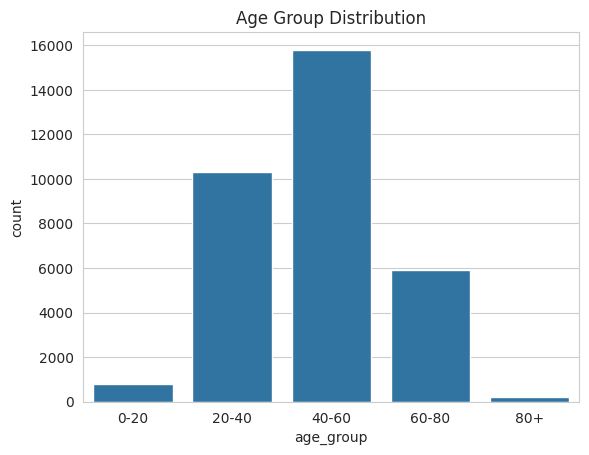

In [ ]:
train_df["age_group"] = pd.cut(
    train_df["age_approx"],
    bins=[0,20,40,60,80,100],
    labels=["0-20","20-40","40-60","60-80","80+"]
)

sns.countplot(x="age_group", data=train_df)
plt.title("Age Group Distribution")
plt.show()

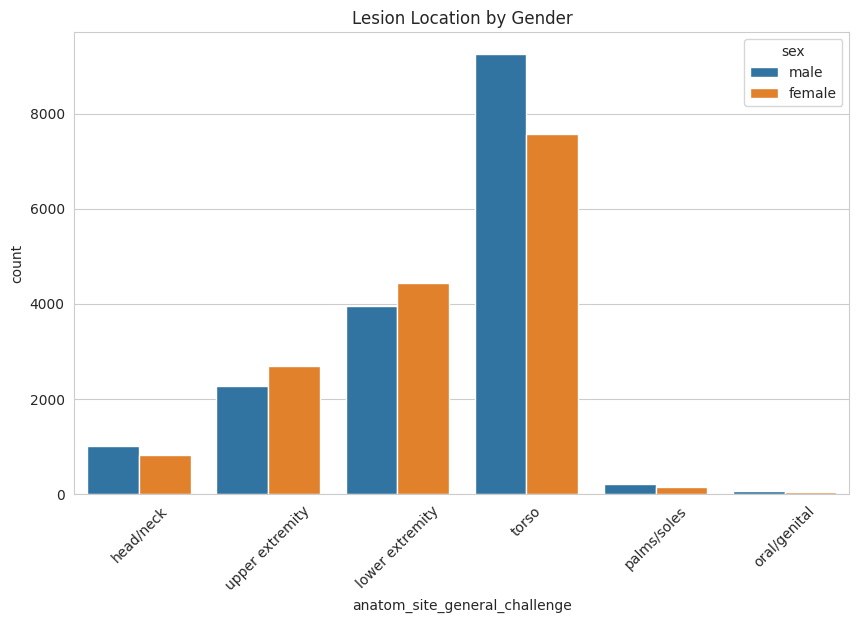

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x="anatom_site_general_challenge", hue="sex", data=train_df)
plt.xticks(rotation=45)
plt.title("Lesion Location by Gender")
plt.show()

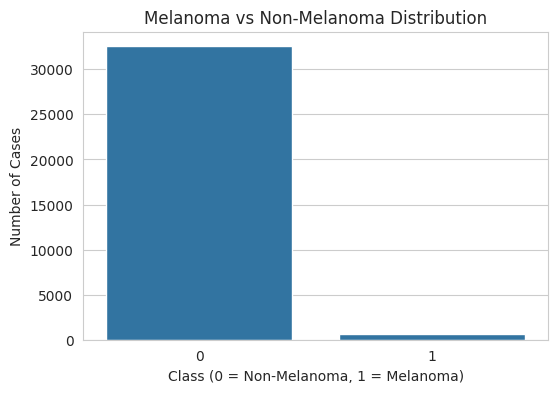

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='target', data=train_df)

plt.title("Melanoma vs Non-Melanoma Distribution")
plt.xlabel("Class (0 = Non-Melanoma, 1 = Melanoma)")
plt.ylabel("Number of Cases")

plt.show()

In [ ]:
# Total samples
total_cases = len(train_df)

# Melanoma (target = 1)
melanoma_cases = train_df['target'].sum()

# Non-melanoma (target = 0)
non_melanoma_cases = total_cases - melanoma_cases

print("Total cases:", total_cases)
print("Melanoma cases:", melanoma_cases)
print("Non-melanoma cases:", non_melanoma_cases)

Total cases: 33126
Melanoma cases: 584
Non-melanoma cases: 32542


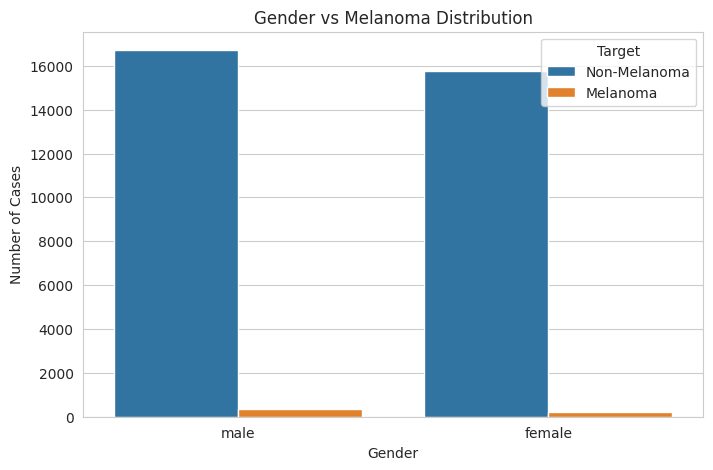

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='sex', hue='target', data=train_df)

plt.title("Gender vs Melanoma Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Cases")
plt.legend(title="Target", labels=["Non-Melanoma", "Melanoma"])

plt.show()

In [ ]:
# Load dataset
df = pd.read_csv(os.path.join(path, "ISIC_2020_Dataset", "ISIC_2020_Train_Metadata.csv"))

# Grouping: Gender vs Melanoma
summary = df.groupby(['sex', 'target']).size().unstack(fill_value=0)

# Rename columns for clarity
summary.columns = ['Non-Melanoma (0)', 'Melanoma (1)']

print("Gender vs Melanoma Distribution:\n")
print(summary)

# Total counts
print("\nTotal Cases by Gender:\n")
print(df['sex'].value_counts())

Gender vs Melanoma Distribution:

        Non-Melanoma (0)  Melanoma (1)
sex                                   
female             15761           220
male               16716           364

Total Cases by Gender:

sex
male      17080
female    15981
Name: count, dtype: int64


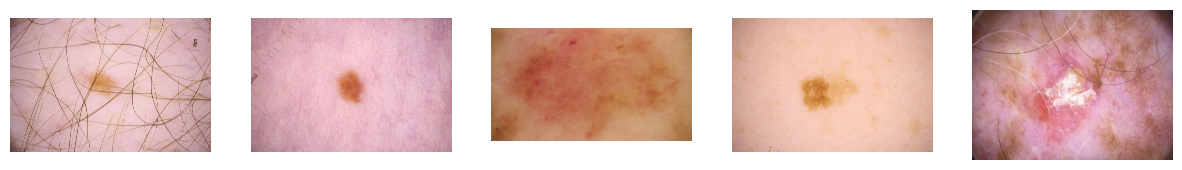

In [ ]:
from PIL import Image

img_path = os.path.join(path, "ISIC_2020_Dataset", "train") + os.sep

sample = train_df.sample(5)

plt.figure(figsize=(15,5))

for i, img in enumerate(sample["image_name"]):
    plt.subplot(1,5,i+1)
    image = Image.open(img_path + img + ".jpg")
    plt.imshow(image)
    plt.axis("off")

plt.show()

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Changed 'age_approx' to 'age_group' as it's already a categorical representation
cols = ["sex", "age_group", "anatom_site_general_challenge"]

for col in ["age_group", "anatom_site_general_challenge", "sex"]:

    if isinstance(train_df[col].dtype, pd.CategoricalDtype):
        if "unknown" not in train_df[col].cat.categories:
            train_df[col] = train_df[col].cat.add_categories("unknown")

    elif train_df[col].dtype == 'object':
        train_df[col] = train_df[col].astype('category')
        if "unknown" not in train_df[col].cat.categories:
            train_df[col] = train_df[col].cat.add_categories("unknown")

encoder = OneHotEncoder(handle_unknown="ignore")

encoded = encoder.fit_transform(
    train_df[cols].fillna("unknown")
).toarray()

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cols))

train_df = pd.concat([train_df, encoded_df], axis=1)

meta_features = encoded_df.columns.tolist()

print("Number of metadata features:", len(meta_features))

Number of metadata features: 16


In [ ]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [ ]:
from sklearn.model_selection import train_test_split
train_df.dropna(subset=['image_name', 'target'], inplace=True)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["target"],
    random_state=42
)

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import torch
class MelanomaDataset(Dataset):

    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img_name = str(row.image_name)
        img_path = os.path.join(
            path,
            "ISIC_2020_Dataset",
            "train",
            img_name + ".jpg"
        )

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        meta_values = row[meta_features].values.astype(np.float32)
        meta = torch.tensor(meta_values)

        label = torch.tensor(row.target).float()

        return image, meta, label

In [ ]:
train_dataset = MelanomaDataset(train_df, transform)
val_dataset = MelanomaDataset(val_df, transform)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
!pip install fastprogress

In [ ]:
from fastprogress.fastprogress import master_bar, progress_bar
from sklearn.metrics import roc_auc_score

In [ ]:
def AUC(outputs, targets):
    outputs = torch.sigmoid(outputs)
    return roc_auc_score(targets.numpy(), outputs.numpy())

In [ ]:
imgs, meta, labels = next(iter(train_loader))

print(imgs.shape)
print(meta.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32, 16])


In [ ]:
batch_size = 1

In [ ]:
train_dataset = MelanomaDataset(train_df, transform)
val_dataset = MelanomaDataset(val_df, transform)

dataloader = {
    "train": DataLoader(train_dataset, batch_size=32, shuffle=True),
    "val": DataLoader(val_dataset, batch_size=32, shuffle=False)
}

In [ ]:
turesfrom fastprogress.fastprogress import master_bar, progress_bar
from sklearn.metrics import roc_auc_score

def AUC(outputs, targets):
    outputs = torch.sigmoid(outputs)
    return roc_auc_score(targets.numpy(), outputs.numpy())


class MelanomaModel_ResNet18(nn.Module):

    def __init__(self, meta_features_len):
        super().__init__()

        resnet = torchvision.models.resnet18(pretrained=True)

        for param in resnet.parameters():
            param.requires_grad = False

        self.image_encoder = nn.Sequential(*list(resnet.children())[:-1])

        self.meta_encoder = nn.Sequential(
            nn.Linear(meta_features_len, 100),
            nn.ReLU(),
            nn.Linear(100, 3),
            nn.ReLU()
        )

        self.classifier = nn.Linear(512 + 3, 1)

    def forward(self, image, meta):
        x = self.image_encoder(image)
        x = x.view(x.size(0), -1)

        m = self.meta_encoder(meta)

        z = torch.cat([x, m], dim=1)
        return self.classifier(z)


model = MelanomaModel_ResNet18(len(meta_features)).to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

criterion = torch.nn.BCEWithLogitsLoss()

epochs = 1
validation_steps = 15

mb = master_bar(range(1, epochs+1))
best_auc = 0

for epoch in mb:

    train_loss = []
    model.train()

    for imgs, meta, labels in progress_bar(train_loader, parent=mb):

        imgs = imgs.to(device)
        meta = meta.to(device)
        labels = labels.unsqueeze(1).to(device)

        outputs = model(imgs, meta)

        optimizer.zero_grad()
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss.append(loss.item())
        mb.child.comment = f'loss: {np.mean(train_loss):.5f}'

    val_loss = []
    model.eval()

    val_outputs = torch.tensor([])
    val_targets = torch.tensor([])

    with torch.no_grad():

        for step, (imgs, meta, labels) in enumerate(progress_bar(val_loader, parent=mb)):

            imgs = imgs.to(device)
            meta = meta.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(imgs, meta)

            loss = criterion(outputs, labels)
            val_loss.append(loss.item())

            val_outputs = torch.cat([val_outputs, outputs.cpu()])
            val_targets = torch.cat([val_targets, labels.cpu()])

            if step > validation_steps:
                break

    auc = AUC(val_outputs, val_targets)

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), "resnet18_best.pth")

    mb.write(
        f'epoch: {epoch} | train_loss: {np.mean(train_loss):.5f} | val_loss: {np.mean(val_loss):.5f} | AUC: {auc:.5f}'
    )

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<div><div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div><div></div><div><progress max="829" value="532"></progress> 64.17% [532/829 20:48&lt;11:37... loss: 0.13520]</div></div>

<div><p>epoch: 1 | train_loss: 0.11710 | val_loss: 0.11599 | AUC: 0.52195</p></div>

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score

# Convert outputs → probabilities
probs = torch.sigmoid(val_outputs).numpy()

# Convert probabilities → predictions
preds = (probs > 0.07).astype(int)

# Targets
targets = val_targets.numpy()

# Metrics
auc = roc_auc_score(targets, probs)
accuracy = accuracy_score(targets, preds)
f1 = f1_score(targets, preds)
precision = precision_score(targets, preds)

print("Final Validation AUC:", auc)
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Precision:", precision)

Final Validation AUC: 0.5219469795740982
Accuracy: 0.9724264705882353
F1 Score: 0.0
Precision: 0.0


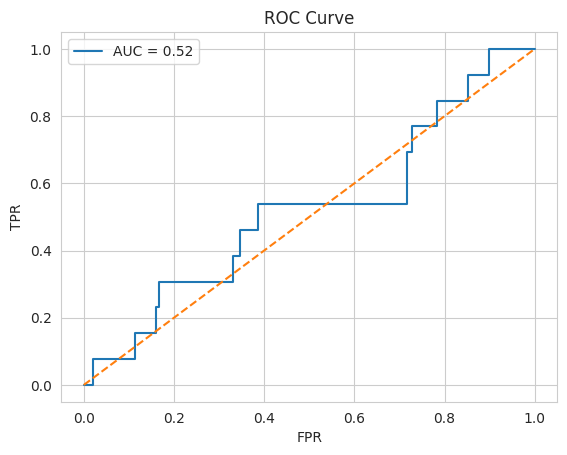

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(targets, probs)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], '--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

RESNET50


In [ ]:
from fastprogress.fastprogress import master_bar, progress_bar
from sklearn.metrics import roc_auc_score
import numpy as np

# AUC function
def AUC(outputs, targets):
    outputs = torch.sigmoid(outputs)
    return roc_auc_score(targets.numpy(), outputs.numpy())


# ResNet50 Multimodal Model
class MelanomaModel(nn.Module):

    def __init__(self, meta_features_len):
        super().__init__()

        resnet = torchvision.models.resnet50(pretrained=True)

        for param in resnet.parameters():
            param.requires_grad = False

        self.image_encoder = nn.Sequential(*list(resnet.children())[:-1])

        self.meta_encoder = nn.Sequential(
            nn.Linear(meta_features_len, 100),
            nn.ReLU(),
            nn.Linear(100, 3),
            nn.ReLU()
        )

        self.classifier = nn.Linear(2048 + 3, 1)

    def forward(self, image, meta):
        x = self.image_encoder(image)
        x = x.view(x.size(0), -1)

        m = self.meta_encoder(meta)

        z = torch.cat([x, m], dim=1)
        return self.classifier(z)


# Initialize
model = MelanomaModel(len(meta_features)).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  # fixed LR
criterion = torch.nn.BCEWithLogitsLoss()

epochs = 1
validation_steps = 15

mb = master_bar(range(1, epochs+1))
best_auc = 0


# TRAINING LOOP
for epoch in mb:

    train_loss = []
    model.train()

    for imgs, meta, labels in progress_bar(train_loader, parent=mb):

        imgs = imgs.to(device)
        meta = meta.to(device)
        labels = labels.unsqueeze(1).to(device)

        outputs = model(imgs, meta)

        optimizer.zero_grad()
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss.append(loss.item())
        mb.child.comment = f'loss: {np.mean(train_loss):.5f}'


    # VALIDATION
    val_loss = []
    model.eval()

    val_outputs = torch.tensor([])
    val_targets = torch.tensor([])

    with torch.no_grad():

        for step, (imgs, meta, labels) in enumerate(progress_bar(val_loader, parent=mb)):

            imgs = imgs.to(device)
            meta = meta.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(imgs, meta)

            loss = criterion(outputs, labels)
            val_loss.append(loss.item())

            val_outputs = torch.cat([val_outputs, outputs.cpu()])
            val_targets = torch.cat([val_targets, labels.cpu()])

            if step > validation_steps:
                break


    # AUC
    auc = AUC(val_outputs, val_targets)

    # Save best model
    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), "resnet50_best.pth")

    # Print results
    mb.write(
        f'epoch: {epoch} | train_loss: {np.mean(train_loss):.5f} | val_loss: {np.mean(val_loss):.5f} | AUC: {auc:.5f}'
    )

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


<div><div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div><div></div><div><progress max="829" value="762"></progress> 91.92% [762/829 27:20&lt;02:24... loss: 0.10770]</div></div>

<div><p>epoch: 1 | train_loss: 0.10603 | val_loss: 0.12507 | AUC: 0.28538</p></div>

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, roc_curve, auc
import matplotlib.pyplot as plt

# Convert outputs → probabilities
probs = torch.sigmoid(val_outputs).numpy()

# Convert probabilities → predictions
preds = (probs > 0.07).astype(int)

# Targets
targets = val_targets.numpy()

#Metrics
accuracy = accuracy_score(targets, preds)
f1 = f1_score(targets, preds)
precision = precision_score(targets, preds)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Precision:", precision)

# ┅ ROC + AUC
fpr, tpr, thresholds = roc_curve(targets, probs)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)


Accuracy: 0.9761029411764706
F1 Score: 0.0
Precision: 0.0
AUC: 0.2853831667390989


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


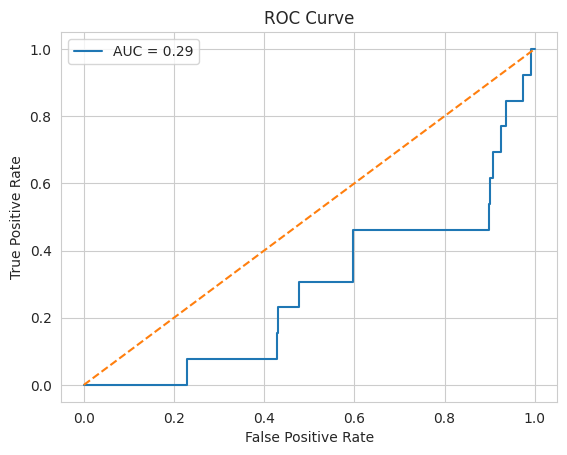

In [ ]:
#Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MelanomaModel(nn.Module):

    def __init__(self, meta_features_len):

        super().__init__()

        resnet = torchvision.models.resnet101(pretrained=True)

        for param in resnet.parameters():
            param.requires_grad = False

        self.image_encoder = nn.Sequential(
            *list(resnet.children())[:-1]
        )

        self.meta_encoder = nn.Sequential(
            nn.Linear(meta_features_len,100),
            nn.ReLU(),
            nn.Linear(100,3),
            nn.ReLU()
        )

        self.classifier = nn.Linear(2048 + 3, 1)

    def forward(self, image, meta):

        x = self.image_encoder(image)
        x = x.view(x.size(0), -1)

        m = self.meta_encoder(meta)

        z = torch.cat([x,m], dim=1)

        return self.classifier(z)

model = MelanomaModel(len(meta_features)).to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:00<00:00, 199MB/s]


In [ ]:
from fastprogress.fastprogress import master_bar, progress_bar
from sklearn.metrics import roc_auc_score

def AUC(outputs, targets):
    outputs = torch.sigmoid(outputs)
    return roc_auc_score(targets.numpy(), outputs.numpy())

model = MelanomaModel(len(meta_features)).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.BCEWithLogitsLoss()

epochs = 1
validation_steps = 15

mb = master_bar(range(1, epochs+1))
best_auc = 0

model.to(device)

for epoch in mb:

    train_loss = []
    model.train()

    for imgs, meta, labels in progress_bar(train_loader, parent=mb):

        imgs = imgs.to(device)
        meta = meta.to(device)

        # fixing the label shape
        labels = labels.unsqueeze(1).to(device)

        outputs = model(imgs, meta)

        optimizer.zero_grad()

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss.append(loss.item())

        mb.child.comment = f'loss: {np.mean(train_loss):.5f}'

    val_loss = []
    model.eval()

    validation_step = 0

    val_outputs = torch.tensor([])
    val_targets = torch.tensor([])

    with torch.no_grad():

        for imgs, meta, labels in progress_bar(val_loader, parent=mb):

            imgs = imgs.to(device)
            meta = meta.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(imgs, meta)

            loss = criterion(outputs, labels)

            val_loss.append(loss.item())

            mb.child.comment = f'val_loss: {np.mean(val_loss):.5f}'

            val_outputs = torch.cat([val_outputs, outputs.cpu()])
            val_targets = torch.cat([val_targets, labels.cpu()])

            validation_step += 1

            if validation_step > validation_steps:
                break


    #Area under cover(AUC)
    auc = AUC(val_outputs, val_targets)


    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), "model.pth")


    # Printing Results
    mb.write(
        f'epoch: {epoch} | train_loss: {np.mean(train_loss):.5f} | val_loss: {np.mean(val_loss):.5f} | auc_loss: {auc:.5f}'
    )

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<div><p>epoch: 1 | train_loss: 0.14833 | val_loss: 0.11498 | auc_loss: 0.78983</p></div>

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    val_targets.numpy(),
    torch.sigmoid(val_outputs).numpy()
)

print("Final Validation AUC:", auc)

Final Validation AUC: 0.7898333333333334


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# converting probabilities to binary predictions
probs = torch.sigmoid(val_outputs).numpy()
preds = (probs > 0.07).astype(int)

targets = val_targets.numpy()

# metrics
accuracy = accuracy_score(targets, preds)
f1 = f1_score(targets, preds)
precision = precision_score(targets, preds)
sensitivity = recall_score(targets, preds)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}")

Accuracy: 0.9297
F1 Score: 0.2174
Precision: 0.1471
Sensitivity (Recall): 0.4167


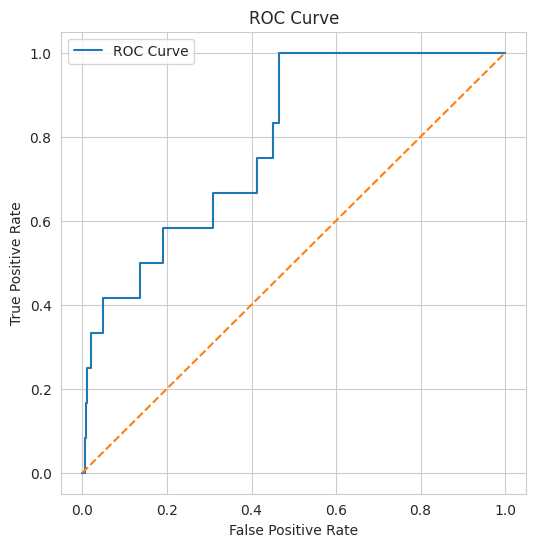

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(
    val_targets.numpy(),
    torch.sigmoid(val_outputs).numpy()
)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()

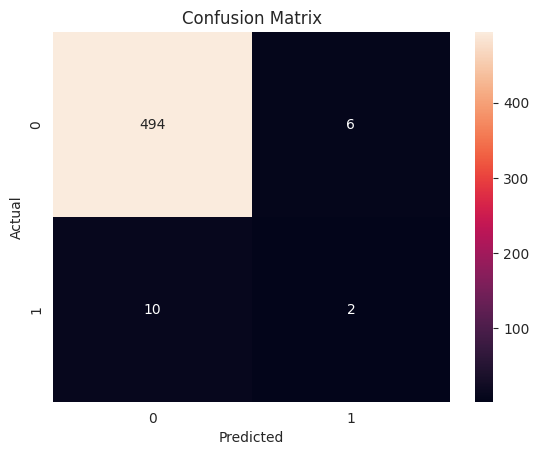

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

preds = (torch.sigmoid(val_outputs) > 0.3).int()

cm = confusion_matrix(
    val_targets.numpy(),
    preds.numpy()
)

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

EXPLINABLE AI

Using Colab cache for faster access to the 'isic-challenge-dataset-2020' dataset.


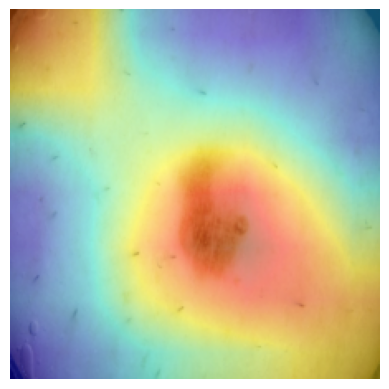

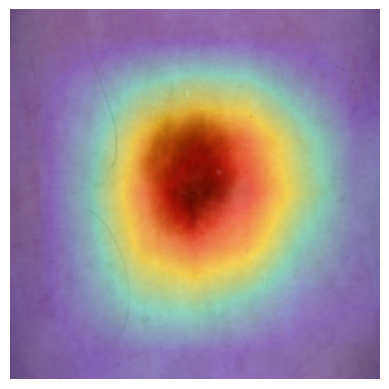

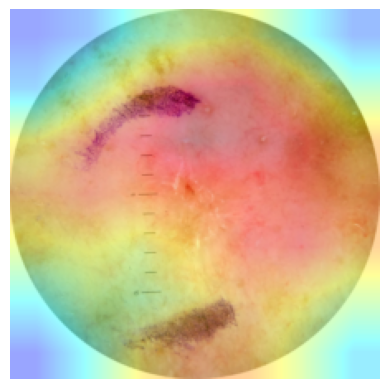

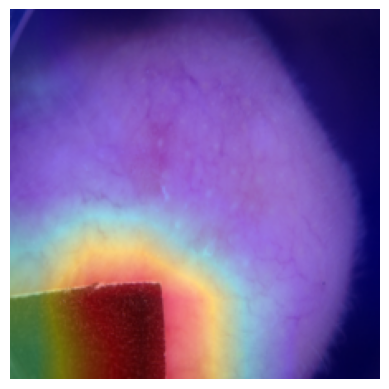

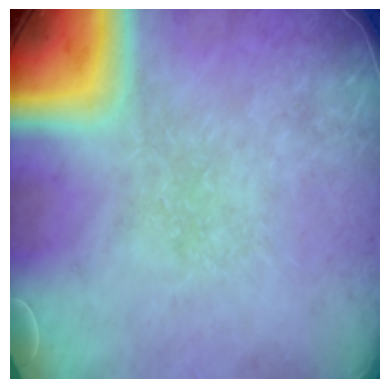

In [ ]:
import kagglehub
import os
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

path = kagglehub.dataset_download(
    "sumaiyabinteshahid/isic-challenge-dataset-2020"
)
dataset_root = os.path.join(path, "ISIC_2020_Dataset")
csv_path = os.path.join(dataset_root, "ISIC_2020_Train_Metadata.csv")
df = pd.read_csv(csv_path)
image_dir = os.path.join(dataset_root, "train")
df["image_path"] = df["image_name"].apply(lambda x: f"{image_dir}/{x}.jpg")

class ISICDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["image_path"]
        label = self.df.iloc[idx]["target"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        meta = torch.zeros(10)

        return image, meta, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

melanoma_df = df[df["target"] == 1].reset_index(drop=True)

dataset = ISICDataset(melanoma_df, transform=transform)
val_loader = DataLoader(dataset, batch_size=4, shuffle=True)

# GRAD-CAM FUNCTION
def generate_gradcam_batch(model, dataloader, device, num_images=5):

    gradients = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    target_layer = model.layer4[-1]

    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_full_backward_hook(backward_hook)

    count = 0

    for imgs, meta, labels in dataloader:

        for i in range(imgs.size(0)):

            if count >= num_images:
                break

            gradients.clear()
            activations.clear()

            img = imgs[i].unsqueeze(0).to(device)

            output = model(img)

            class_idx = output.argmax(dim=1)
            score = output[0, class_idx]

            model.zero_grad()
            score.backward()

            grads = gradients[0].cpu().detach().numpy()[0]
            acts = activations[0].cpu().detach().numpy()[0]

            weights = np.mean(grads, axis=(1, 2))

            cam = np.zeros(acts.shape[1:], dtype=np.float32)

            for j, w in enumerate(weights):
                cam += w * acts[j]

            cam = np.maximum(cam, 0)
            cam = cam / (cam.max() + 1e-8)

            cam = cv2.resize(cam, (224, 224))

            heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)

            img_np = img.cpu().detach().numpy()[0].transpose(1, 2, 0)
            img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

            overlay = heatmap * 0.4 + img_np * 255 * 0.6
            overlay = np.clip(overlay, 0, 255).astype(np.uint8)

            plt.imshow(overlay)
            plt.axis('off')
            plt.show()

            count += 1

        if count >= num_images:
            break

    handle_f.remove()
    handle_b.remove()

# ================== RUN ==================
generate_gradcam_batch(model, val_loader, device, num_images=5)